### Task 1

Processed 500 commits so far
Processed 1000 commits so far
Processed 1500 commits so far
Processed 2000 commits so far
Processed 2500 commits so far
Processed 3000 commits so far
Processed 3500 commits so far
Processed 4000 commits so far
Processed 4500 commits so far
Processed 5000 commits so far
Processed 5500 commits so far
Processed 6000 commits so far
Processed 6500 commits so far
Processed 7000 commits so far
Processed 7500 commits so far
Processed 8000 commits so far
Processed 8500 commits so far
Total commits processed: 8817
Files with most defects: [('src\\transformers\\modeling_utils.py', 367), ('src\\transformers\\__init__.py', 314)]
Finished processing.


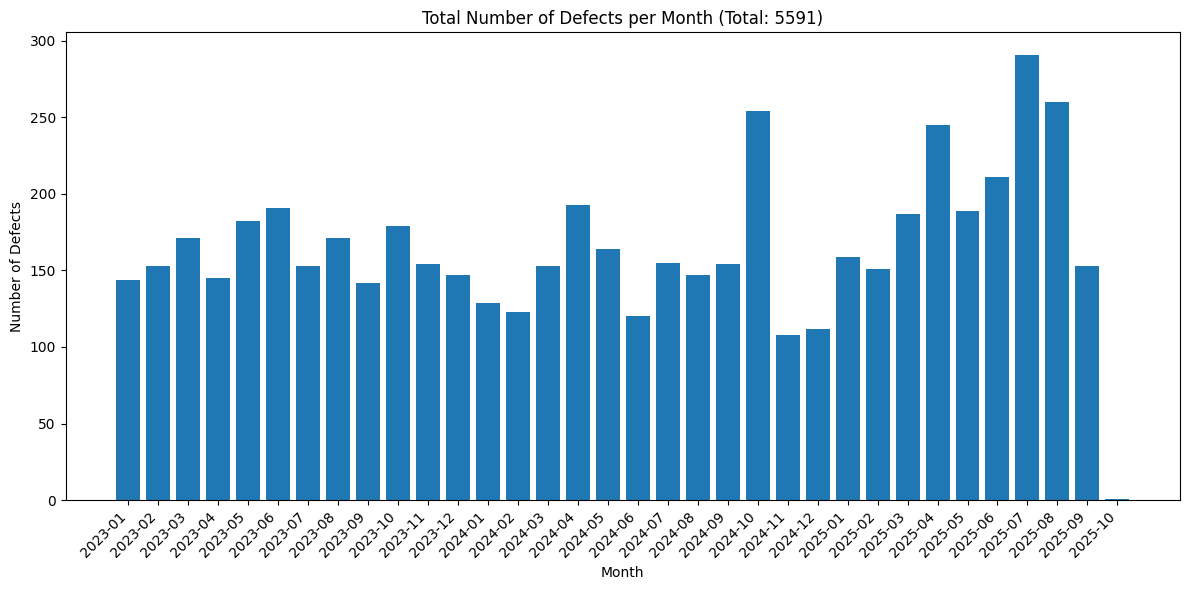

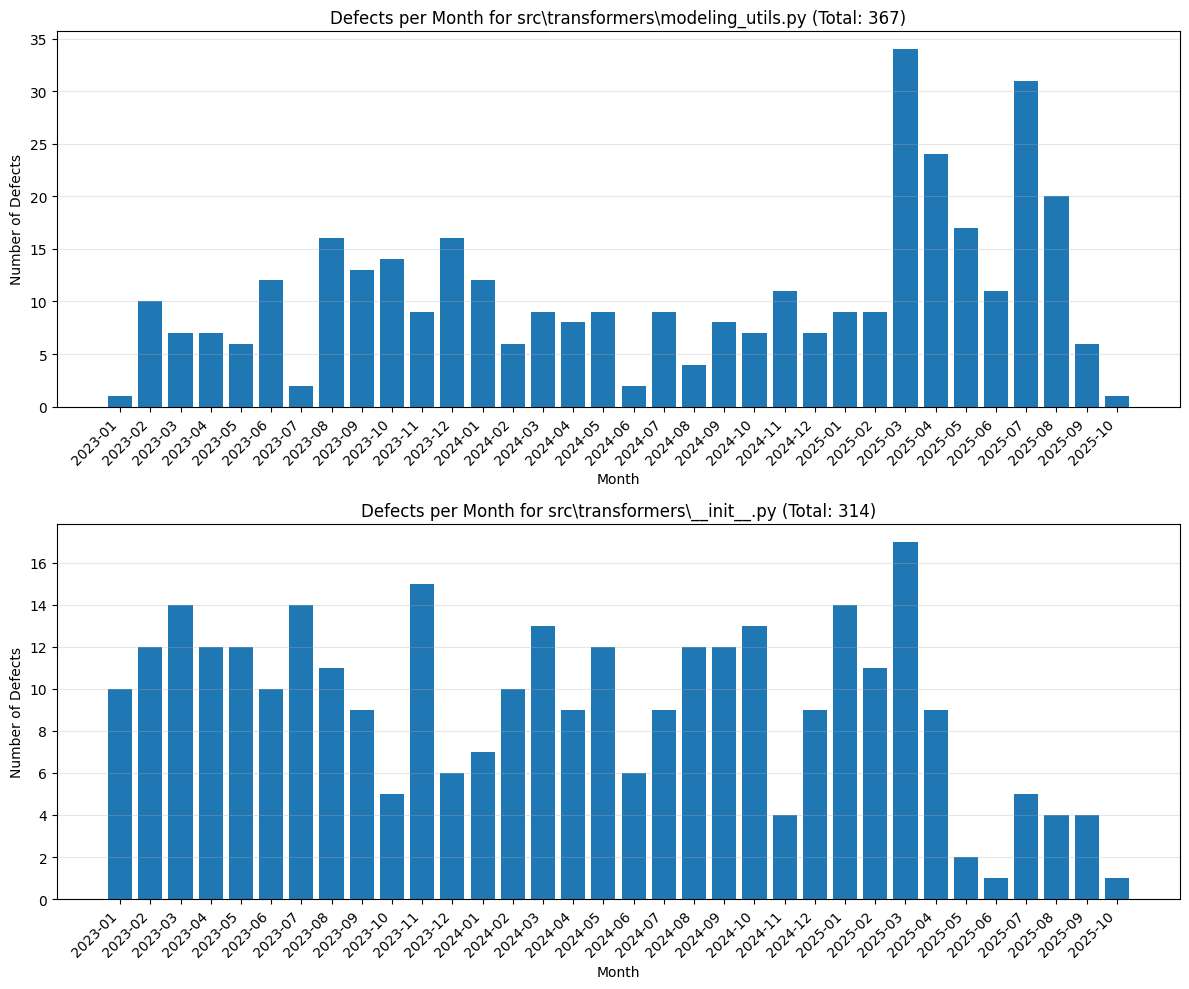

In [ ]:
from pydriller import Repository
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt


repository = "" #local URL to cloned repo, checkout tag v4.57.0 
#tag = "v4.57.0"
date = datetime(2023, 1, 1)
keywords = ['bug', 'fix', 'error', 'issue', 'bugfix', 'hotfix', 'patch']

defects_per_month = defaultdict(int)  #{(year, month): count}
defects_per_file = defaultdict(int)   #{filename: count}
count = 0
total_defects = 0
for commit in Repository(repository, since=date).traverse_commits():
    count += 1
    message = commit.msg.lower()  #ignore casing
    isKeywordPresent = any(word in message for word in keywords)

    if isKeywordPresent:
        total_defects += 1
        year_month = (commit.committer_date.year, commit.committer_date.month)
        defects_per_month[year_month] += 1

        for file in commit.modified_files:
            defects_per_file[file.new_path] += 1

    if count % 500 == 0:
        print(f"Processed {count} commits so far")

print(f"Total commits processed: {count}")

#Task 1
months = sorted(defects_per_month.keys())
defect_counts = [defects_per_month[month] for month in months]
month_labels = [f"{year}-{month:02d}" for year, month in months]

plt.figure(figsize=(12, 6))
plt.bar(range(len(months)), defect_counts)
plt.xlabel('Month')
plt.ylabel('Number of Defects')
plt.title(f'Total Number of Defects per Month (Total: {total_defects})')
plt.xticks(range(len(months)), month_labels, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('TASK1_defects_per_month.png')


#Task 2
top_2_files = sorted(defects_per_file.items(), key=lambda x: x[1], reverse=True)[:2]
file1_path, file1_count = top_2_files[0]
file2_path, file2_count = top_2_files[1]
print(f"Files with most defects: {top_2_files}")

def get_file_defects_per_month(filepath):
    file_defects_per_month = defaultdict(int)
    
    for commit in Repository(repository, since=date, filepath=filepath).traverse_commits():
        message = commit.msg.lower() #ignore casing
        isKeywordPresent = any(word in message for word in keywords)
        
        if isKeywordPresent:
            year_month = (commit.committer_date.year, commit.committer_date.month)
            file_defects_per_month[year_month] += 1
        
    return file_defects_per_month

file1_defects_per_month = get_file_defects_per_month(file1_path)
file2_defects_per_month = get_file_defects_per_month(file2_path)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
#Plot for file 1
months_file1 = sorted(file1_defects_per_month.keys())
counts_file1 = [file1_defects_per_month[month] for month in months_file1]
labels_file1 = [f"{year}-{month:02d}" for year, month in months_file1]

ax1.bar(range(len(months_file1)), counts_file1)
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Defects')
ax1.set_title(f'Defects per Month for {file1_path} (Total: {file1_count})')
ax1.set_xticks(range(len(months_file1)))
ax1.set_xticklabels(labels_file1, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

#Plot for file 2
months_file2 = sorted(file2_defects_per_month.keys())
counts_file2 = [file2_defects_per_month[month] for month in months_file2]
labels_file2 = [f"{year}-{month:02d}" for year, month in months_file2]

ax2.bar(range(len(months_file2)), counts_file2)
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Defects')
ax2.set_title(f'Defects per Month for {file2_path} (Total: {file2_count})')
ax2.set_xticks(range(len(months_file2)))
ax2.set_xticklabels(labels_file2, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('TASK1_top2_files_defects_per_month.png')

print("Finished processing.")

### Task 2